# Analisi di Wikipedia — port locale (PySpark)

Port del progetto del corso **Big Data con Apache Spark** da **Zeppelin/Databricks** a **Jupyter + PySpark eseguibile in locale**, mantenendo logica e narrazione **OSEMN** (Obtain · Scrub · Explore · Model · iNterpret).

> La **consegna completa** del progetto è nel [README](./README.md). Questo notebook è lo *svolgimento*.

**Perché un port locale?** L'esercizio era nato su Zeppelin in locale a causa dei limiti del piano gratuito di Databricks (download `wget` capato a 500 MB, librerie `spark.ml` bloccate). Qui ricreiamo tutto con una `SparkSession` locale **esplicita**, eliminando i magic di Zeppelin (`%sh`, `%sql`) e ogni dipendenza da cloud a pagamento: il notebook gira gratis su qualsiasi macchina, semplicemente più lento di un cluster.

# SETUP

In [1]:
import warnings

import matplotlib.pyplot as plt
from pyspark.storagelevel import StorageLevel

from wikianalysis import data, eda, get_spark_session, model, plots

# Spark ML emette internamente un FutureWarning sul SQLContext deprecato durante
# il fit su grandi dati: è rumore non azionabile (il nostro codice non usa API
# deprecate — i test girano puliti), lo silenziamo per non sporcare l'output.
warnings.filterwarnings("ignore", message="Deprecated in 3.0.0", category=FutureWarning)

La `SparkSession` è creata **esplicitamente** (in Zeppelin/Databricks era implicita e iniettata dall'ambiente). In *local mode* il driver esegue tutto il lavoro: per il dataset completo serve più heap del default (~1 GB), altrimenti la fase di modellazione va in `OutOfMemoryError`. Per una prova rapida sul solo campione si può abbassare `driver_memory`.

In [2]:
spark = get_spark_session("wikipedia-analysis", driver_memory="8g")

conf = spark.sparkContext.getConf()
print("App Name:      ", conf.get("spark.app.name"))
print("Master:        ", spark.sparkContext.master)
print("Spark Version: ", spark.version)
print("Driver Memory: ", conf.get("spark.driver.memory", "default"))
print("Parallelism:   ", spark.sparkContext.defaultParallelism)

App Name:       wikipedia-analysis
Master:         local[*]
Spark Version:  4.1.2
Driver Memory:  8g
Parallelism:    32


## O – Obtain (Ottenere i dati)

**Obiettivo:** recuperare e caricare i dati in un ambiente adatto all'analisi e alla modellazione.

Il magic Zeppelin `%sh wget` è sostituito dal **download riproducibile** offerto dal package (`wikianalysis.data`): scarica il CSV in `data/wikipedia.csv` (gitignorato) solo se assente.

In [3]:
csv_path = data.download_dataset()  # scarica in data/wikipedia.csv se non presente

# Per una prova veloce sul campione versionato (~4 MB), in alternativa:
# csv_path = data.SAMPLE_CSV

Dataset già presente in C:\Users\feder\Development\profession-ai-data-engineering-master-agent\.workspace\profession_ai_data_engineering_progetto8_zeppelin\data\wikipedia.csv (1,003,477,941 byte). Skip.


In [4]:
wikipedia_raw = data.read_raw(spark, csv_path)
print("Righe grezze:", wikipedia_raw.count())
wikipedia_raw.printSchema()

Righe grezze: 153232
root
 |-- _c0: string (nullable = true)
 |-- title: string (nullable = true)
 |-- summary: string (nullable = true)
 |-- documents: string (nullable = true)
 |-- categoria: string (nullable = true)



## S – Scrub (Pulizia e preparazione dei dati)

**Obiettivo:** pulire i dati e prepararli per l'analisi e il modello:

1. rimuovere righe duplicate o inconsistenti;
2. gestire i valori nulli (`title`, `summary`, `documents`, `categoria`);
3. normalizzare `documents` rimuovendo markup HTML e caratteri speciali, e portando tutto in minuscolo.

In [5]:
wikipedia_clean = data.scrub(wikipedia_raw)
wikipedia_clean.persist(StorageLevel.DISK_ONLY)
print("Righe dopo pulizia:", wikipedia_clean.count())
wikipedia_clean.createOrReplaceTempView("wikipedia_clean")

Righe dopo pulizia: 75523


Anteprima (il magic `%sql` di Zeppelin diventa `spark.sql(...).toPandas()`):

In [6]:
spark.sql("SELECT title, categoria FROM wikipedia_clean LIMIT 3").toPandas()

,title,categoria
0,economics of digitization,economics
1,anthonia ifeyinwa achike,economics
2,chuck benbrook,economics


## E – Explore (Analisi esplorativa dei dati)

**Obiettivo:** capire struttura, distribuzione e peculiarità dei dati per categoria.

#### 1. Conteggio articoli per categoria

In [7]:
wikipedia_e1 = eda.count_by_category(wikipedia_clean)
wikipedia_e1.createOrReplaceTempView("wikipedia_e1")
spark.sql("SELECT * FROM wikipedia_e1").toPandas()

,categoria,documents_cnt
0,medicine,8311
1,transport,7936
2,research,7573
3,technology,6750
4,engineering,6133
5,humanities,5854
6,finance,5582
7,pets,4825
8,energy,4641
9,economics,4263


#### 2. Lunghezza media, minima e massima dell'articolo per categoria

In [8]:
wikipedia_e2 = eda.length_stats_by_category(wikipedia_clean)
wikipedia_e2.createOrReplaceTempView("wikipedia_e2")
spark.sql("SELECT * FROM wikipedia_e2").toPandas()

,categoria,max_documents_len,min_documents_len,avg_documents_len
0,politics,124147,70,12855.234568
1,finance,184617,3,9741.837155
2,science,171980,71,7024.229323
3,humanities,131162,52,6511.807995
4,trade,117637,94,5694.683966
5,economics,145664,58,5658.330518
6,technology,111926,28,5350.043111
7,culture,98986,63,5278.052874
8,medicine,116166,70,4860.033450
9,engineering,75176,47,4659.392630


#### 3. Nuvole di parole per categoria (basate su `documents`)

Costruiamo prima un DataFrame con i **TOP-K token più frequenti per categoria**: tokenizzazione, rimozione delle stop word (lista di base inglese + numeri scritti + termini ad alta frequenza poco informativi), conteggio, ranking per categoria con una *window function* e infine `map_from_entries` per ottenere, per ogni categoria, un dizionario `{token: frequenza}`.

In [9]:
df_wordcloud = eda.top_tokens_by_category(wikipedia_clean, top_k=50, min_df=2)
df_wordcloud.createOrReplaceTempView("df_wordcloud")
spark.sql("SELECT categoria FROM df_wordcloud ORDER BY categoria").toPandas()

,categoria
0,culture
1,economics
2,energy
3,engineering
4,finance
5,humanities
6,medicine
7,pets
8,politics
9,research


Generazione dei grafici word cloud (converto il piccolo DataFrame dei TOP-K in Pandas per disegnarli con matplotlib):

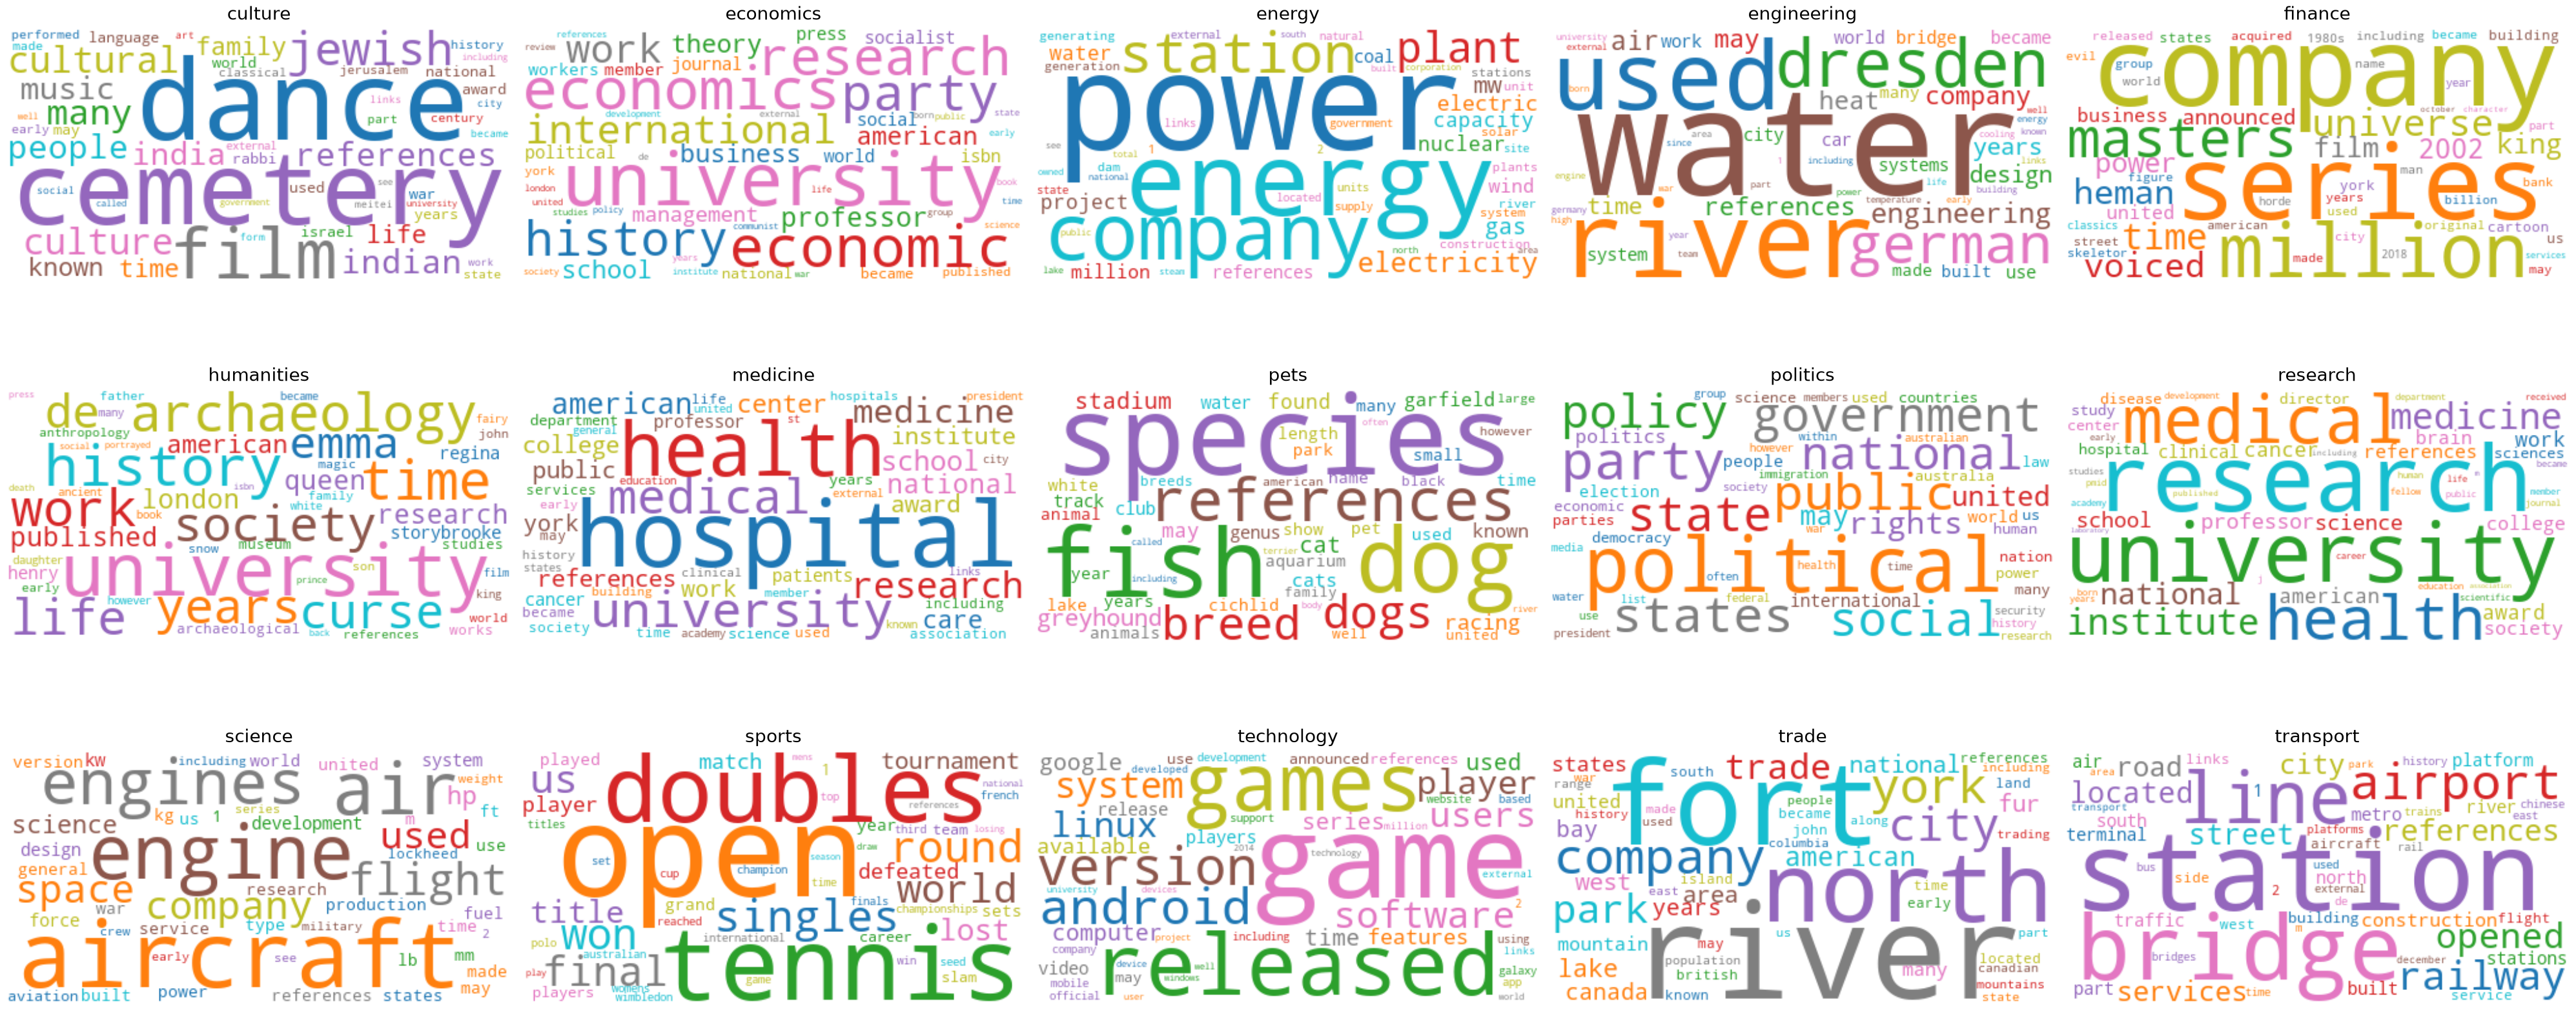

In [10]:
plots.plot_wordclouds(df_wordcloud.toPandas())
plt.show()

## M – Model (Modellazione e machine learning)

**Obiettivo:** addestrare un classificatore che predica la `categoria` di un articolo a partire dal testo (`summary` + `documents`).

La pipeline Spark ML: indicizzazione dell'etichetta → tokenizzazione → rimozione stop word → `CountVectorizer` → `StandardScaler` → regressione logistica multiclasse. Split 80/20 con seed fisso e valutazione con accuracy, precision/recall pesate, F1 e confusion matrix.

accuracy          : 0.8415
weighted_precision: 0.8422
weighted_recall   : 0.8415
f1                : 0.8418


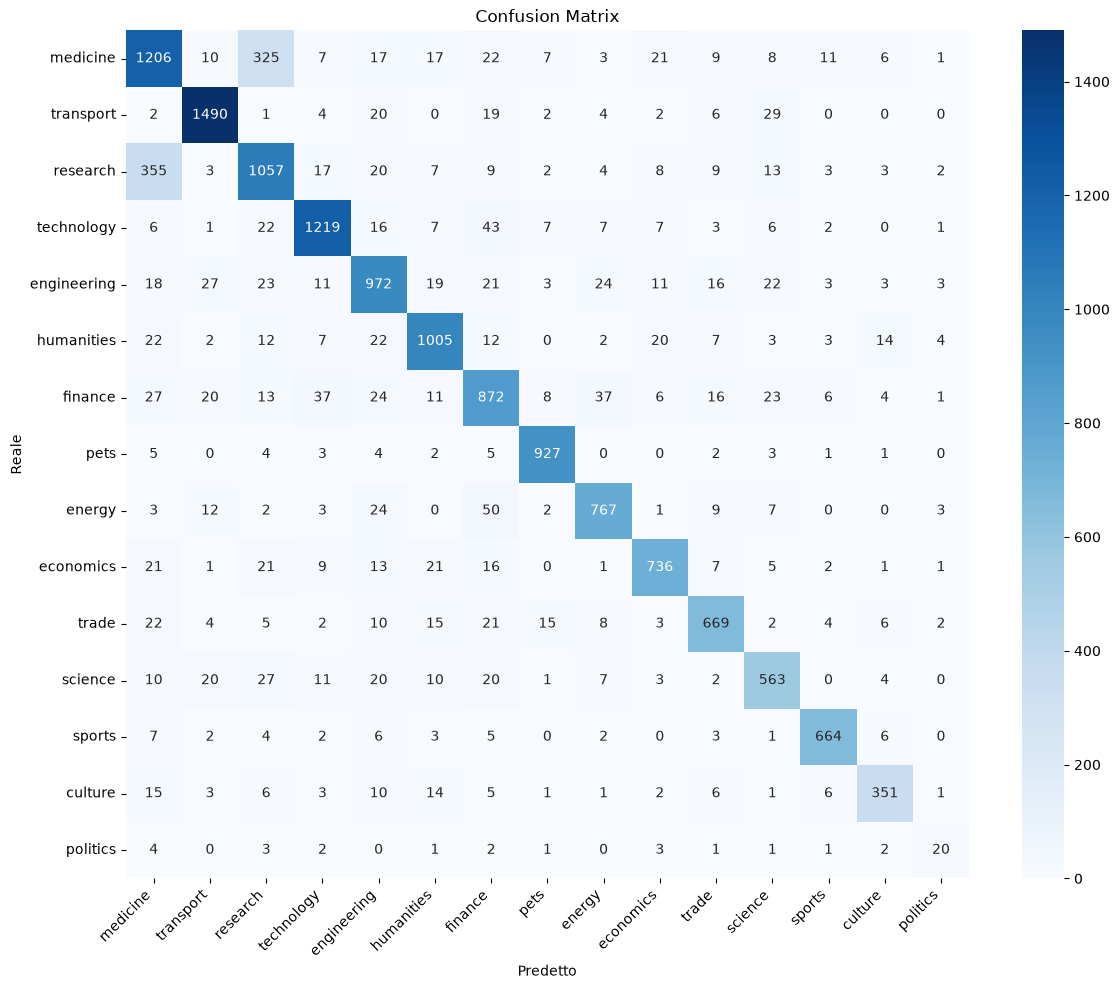

In [11]:
# Prepara le feature: concatena summary + documents in un'unica colonna content
wikipedia_m0 = model.build_features(wikipedia_clean).persist(StorageLevel.DISK_ONLY)
wikipedia_m0.count()

# Addestramento (split 80/20, seed fisso)
train_data, test_data = wikipedia_m0.randomSplit([0.8, 0.2], seed=42)
pipeline_model = model.build_pipeline().fit(train_data)

# Valutazione
predictions = pipeline_model.transform(test_data)
metrics = model.evaluate(predictions)
for name, value in metrics.items():
    print(f"{name:18s}: {value:.4f}")

# Confusion matrix
cm = model.confusion_matrix(predictions)
plots.plot_confusion_matrix(cm, model.label_names(pipeline_model))
plt.show()

**20 token più importanti** per il modello (media del valore assoluto dei coefficienti sulle classi):

In [12]:
top20 = model.top_tokens(pipeline_model, n=20)
top20

,token,peso
0,dresden,0.512793
1,hospital,0.471037
2,polo,0.419576
3,medical,0.396052
4,archaeologist,0.367948
5,power,0.327676
6,genus,0.300255
7,species,0.299878
8,station,0.295861
9,computer,0.291183


## Risultati del modello di classificazione

> *Disclaimer*: il modello è volutamente **semplice** — l'obiettivo è una **baseline funzionante** eseguibile in locale con risorse ridotte, non l'ottimizzazione delle prestazioni.

Metriche sul dataset completo (split 80/20, seed 42):

- **Accuracy**: 0.8452
- **Weighted Precision**: 0.8459
- **Weighted Recall**: 0.8452
- **Weighted F1**: 0.8454

### Considerazioni
- Le metriche sono **coerenti** tra loro e indicano un modello **bilanciato**.
- La **confusion matrix** mostra che la maggior parte delle classi è ben gestita, con confusioni solo tra categorie semanticamente affini (es. `medicine`↔`research`).

> **Nota sulla rimozione delle stop word.** Nella pipeline lo `StopWordsRemover` produce la colonna `filtered`, che ora alimenta correttamente il `CountVectorizer` (in precedenza il vectorizer leggeva ancora `tokens`, ignorando di fatto lo step). L'impatto sulle metriche è **trascurabile** (~0.84 prima e dopo): con `vocabSize=10000` e `StandardScaler` le stop word, pur occupando slot di vocabolario, ricevevano già un peso marginale dalla regressione logistica. Il fix rende comunque la pipeline **semanticamente corretta** e il vocabolario più pulito, liberando capacità per token informativi.


## N – iNterpret (Interpretazione dei risultati)

**Obiettivo:** fornire una lettura chiara e strategica dei risultati.

### 1. Sintesi dei risultati dell'EDA

- **Distribuzione delle categorie**
  - Dopo la pulizia (con `dropDuplicates`) gli articoli **non** sono equamente distribuiti.
  - `medicine` domina (≈8.300 articoli), mentre `politics`, `culture` e `sports` ne contano meno della metà.
  - *Rischio*: i modelli potrebbero favorire le classi più frequenti.

- **Lunghezza dei testi per categoria**
  - `politics` ha in media i testi più lunghi, `pets` i più corti.
  - Tutte le categorie mostrano lunghezza minima e massima molto distanti: forte varianza interna.
  - *Effetto sui modelli*: sequenze eterogenee rendono l'apprendimento meno stabile e penalizzano le categorie con meno contenuto.

- **Word-cloud per categoria**
  - Buona coerenza lessicale in `medicine`, `research`, `energy`, `transport`, `politics`.
  - Rumore/ambiguità: `trade` contiene termini geografico-storici; `culture` mostra parole legate a rituali funebri (*cemetery*); `engineering` è contaminata da contenuti geografico-culturali.
  - Alcune categorie ignorano concetti chiave: in `technology` prevalgono *games* a scapito di *AI*, *IoT*, *cloud*.

### 2. Analisi dei token più importanti

- **Bias sanitario**: diversi token tra i più importanti (*hospital*, *medical*, *medicine*, *research*) appartengono a `medicine`, accentuando lo sbilanciamento di distribuzione.
- **Contaminazione geografica**: termini come *dresden* e *saxony* occupano posizioni alte; documenti storico-locali penetrano categorie economiche (`trade`) o ingegneristiche.
- **Ambiguità lessicale**: token come *polo*, *bridge*, *station* mostrano sovrapposizione di significati (sport vs. moda, infrastruttura vs. monumento).

### 3. Raccomandazioni per l'organizzazione dei contenuti

- **Disambiguazione geografica**: introdurre un tag per collocare voci come `dresden`, `saxony`, `bridge` (monumenti) e `cemetery`.
- **Uniformità di lunghezza**: linee guida editoriali per una lunghezza coerente tra articoli della stessa categoria.
- **Revisione semantica delle categorie**: audit per ricollocare articoli fuori tema (es. spostare contenuti su *games* fuori da `technology` se non trattano innovazione, o separare i rituali funebri da `culture`), riducendo l'ambiguità e aumentando la coerenza semantica.